In [67]:
%pip install opencv-python
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Task 1: Object-Oriented Grocery Manager

In [69]:
class GroceryManager:
    def __init__(self):
        self.grocery_list = []

    def add_item(self, item, quantity, price):
        self.grocery_list.append((item, quantity, price))

    def remove_item(self, item):
        for (it, q, p) in self.grocery_list:
            if it == item:
                self.grocery_list.remove((it, q, p))
                print(f"Removed {item} from the grocery list.\n")
                break
        else:
            print(f"{item} not found in the grocery list.\n")

    def view_list(self):
        print("Grocery List:")
        for (item, quantity, price) in self.grocery_list:
            print(f"{item}: ${price} - {quantity} units")
        print()

    def calculate_total(self):
        return sum(price * quantity for (_, quantity, price) in self.grocery_list)

def task1():
    manager = GroceryManager()
    manager.add_item("Apples", 5, 0.5)
    manager.add_item("Bananas", 3, 0.3)
    manager.view_list()
    print(f"Total cost: ${manager.calculate_total()}\n")
    manager.remove_item("Bananas")
    print("After removing Bananas:")
    manager.view_list()

task1()

Grocery List:
Apples: $0.5 - 5 units
Bananas: $0.3 - 3 units

Total cost: $3.4

Removed Bananas from the grocery list.

After removing Bananas:
Grocery List:
Apples: $0.5 - 5 units



### Task 2: Advanced Student Record System

In [70]:
def task2():
    students = {
        23: {
            "Name": "Umar",
            "Major": "AI",
            "Grades": [90, 85, 92]
        },

        12: {
            "Name": "Raghib",
            "Major": "CS",
            "Grades": [75, 80, 78]
        },

        61: {
            "Name": "AR",
            "Major": "AI",
            "Grades": [88, 91, 95]
        },

        62: {
            "Name": "Fahad",
            "Major": "SE",
            "Grades": [95, 97, 93]
        },

        65: {
            "Name": "Talha",
            "Major": "CS",
            "Grades": [70, 65, 72]
        }
    }

    def top_student(student_dict):
        best_name = None
        best_average = float("-inf")
        for info in student_dict.values():
            grades = info.get("Grades", [])
            average = sum(grades) / len(grades)
            if average > best_average:
                best_average = average
                best_name = info["Name"]
        return best_name

    def search_by_major(student_dict, major):
        found = False
        print(f"\nStudents enrolled in '{major}':")
        for student_id, info in student_dict.items():
            if info.get("Major", "").lower() == major.lower():
                found = True
                print(f"  ID: {student_id} | Name: {info['Name']}")

        if not found:
            print("  No students found in this major.")

    print("=== Student Records ===")
    for sid, info in students.items():
        print(f"{sid}: {info}")

    print("\n=== Top Student ===")
    print(f"Highest average grade: {top_student(students)}")

    search_by_major(students, "AI")
    search_by_major(students, "CS")
    search_by_major(students, "EE")

task2()

=== Student Records ===
23: {'Name': 'Umar', 'Major': 'AI', 'Grades': [90, 85, 92]}
12: {'Name': 'Raghib', 'Major': 'CS', 'Grades': [75, 80, 78]}
61: {'Name': 'AR', 'Major': 'AI', 'Grades': [88, 91, 95]}
62: {'Name': 'Fahad', 'Major': 'SE', 'Grades': [95, 97, 93]}
65: {'Name': 'Talha', 'Major': 'CS', 'Grades': [70, 65, 72]}

=== Top Student ===
Highest average grade: Fahad

Students enrolled in 'AI':
  ID: 23 | Name: Umar
  ID: 61 | Name: AR

Students enrolled in 'CS':
  ID: 12 | Name: Raghib
  ID: 65 | Name: Talha

Students enrolled in 'EE':
  No students found in this major.


### Task 3: Safe Image Loading & RGB Visualization

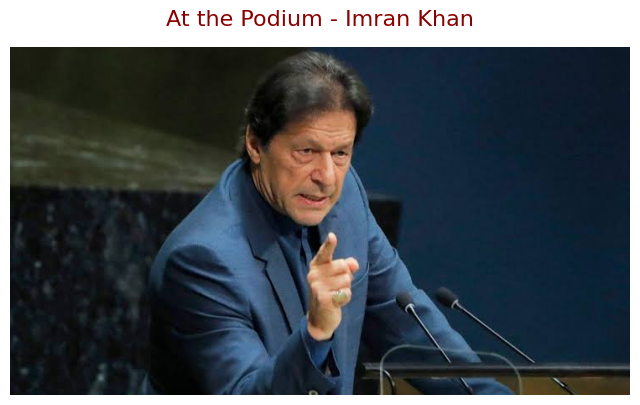

In [71]:
def task3():
    image = cv2.imread('image.jfif')

    if image is None:
        print("Error: Image not found.")
        return

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.title("At the Podium - Imran Khan", fontsize=16, color='darkred', pad=15)
    plt.axis('off')

    plt.imshow(image_rgb)
    plt.show()

task3()

### Task 4: Intercative Geometry & Blank Canvas

Canvas center coordinates: (400, 400)


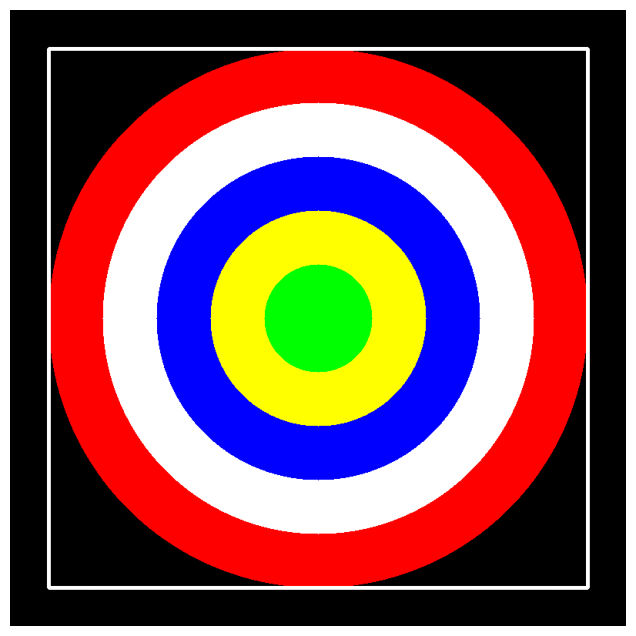

In [72]:
def task4():
    canvas_size = 800
    canvas = np.zeros((canvas_size, canvas_size, 3), dtype=np.uint8)

    mid_x = canvas_size // 2
    mid_y = canvas_size // 2
    center = (mid_x, mid_y)
    print(f"Canvas center coordinates: {center}")

    colors = [
        (0, 0, 255),    # Red
        (255, 255, 255),  # White
        (255, 0, 0),    # Blue
        (0, 255, 255),  # Yellow
        (0, 255, 0),    # Green
    ]

    max_radius = 350
    num_circles = 5
    radius_step = max_radius // num_circles
    radii = [max_radius - (i * radius_step) for i in range(num_circles)]

    for i, radius in enumerate(radii):
        color = colors[i % len(colors)]
        cv2.circle(canvas, center, radius, color, thickness=-1)

    outer_radius = radii[0]
    top_left = (mid_x - outer_radius, mid_y - outer_radius)
    bottom_right = (mid_x + outer_radius, mid_y + outer_radius)

    box_color = (255, 255, 255)  # white bounding box
    cv2.rectangle(canvas, top_left, bottom_right, box_color, thickness=3)

    canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.axis('off')

    plt.imshow(canvas_rgb)
    plt.show()

task4()

### Task 5: Advanced Blurring & Numpy ROI Extraction

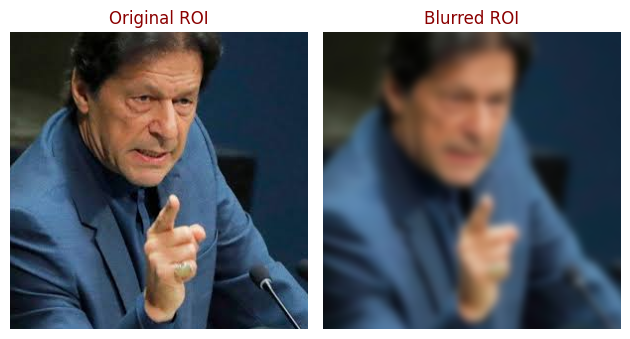

In [73]:
def task5():
    image = cv2.imread('image.jfif')

    if image is None:
        print('Error: Image not found')
        return

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    blurred_image = cv2.GaussianBlur(image_rgb, (25, 25), 0)

    height, width = image_rgb.shape[:2]
    roi = 300

    mid_x, mid_y = width // 2, height // 2
    mid_roi = roi // 2

    x_start = max(mid_x - mid_roi, 0)
    x_end = min(mid_x + mid_roi, width)
    y_start = max(mid_y - mid_roi, 0)
    y_end = min(mid_y + mid_roi, height)

    original_roi = image_rgb[y_start:y_end, x_start:x_end]
    blurred_roi = blurred_image[y_start:y_end, x_start:x_end]

    plt.subplot(1, 2, 1)
    plt.imshow(original_roi)
    plt.title('Original ROI', fontsize=12, color='darkred')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(blurred_roi)
    plt.title('Blurred ROI', fontsize=12, color='darkred')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

task5()

### Task 6: Alpha Blending & Typography

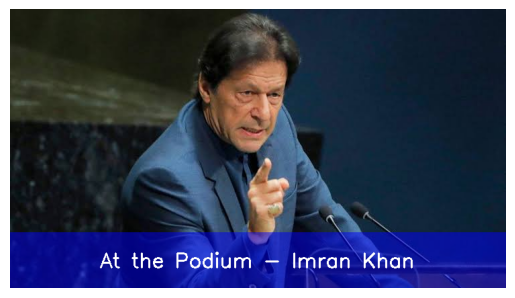

In [74]:
def task6():
    image = cv2.imread('image.jfif')

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    height, width = image_rgb.shape[:2]

    overlay_image = image_rgb.copy()
    band_height = int(height * 0.20)
    y_start = height - band_height

    cv2.rectangle(overlay_image, (0, y_start), (width, height), (0, 0, 255), -1)

    alpha = 0.5
    blended = cv2.addWeighted(overlay_image, alpha, image_rgb, 1 - alpha, 0)

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.0
    thickness = 2
    text_color = (255, 255, 255)
    caption = "At the Podium - Imran Khan"

    (text_width, text_height), _ = cv2.getTextSize(caption, font, font_scale, thickness)
    text_x = (width - text_width) // 2
    text_y = y_start + (band_height + text_height) // 2

    cv2.putText(blended, caption, (text_x, text_y), font, font_scale, text_color, thickness)

    plt.axis('off')

    plt.imshow(blended)
    plt.show()

task6()

### Task 7: Matrix-Based Rotation & Adaptive Thresholding

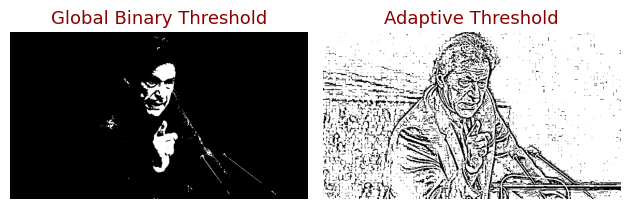

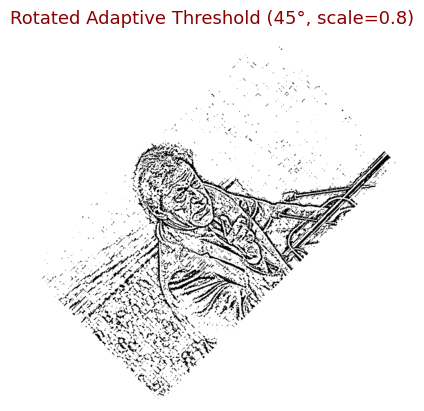

In [75]:
def task7():
    image = cv2.imread('image.jfif', cv2.IMREAD_GRAYSCALE)

    _, global_thresholded_image = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

    adaptive_thresholded_image = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

    plt.subplot(1, 2, 1)
    plt.imshow(global_thresholded_image, cmap='gray')
    plt.axis('off')
    plt.title("Global Binary Threshold", fontsize=13, color='darkred')

    plt.subplot(1, 2, 2)
    plt.title("Adaptive Threshold", fontsize=13, color='darkred')
    plt.axis('off')
    plt.imshow(adaptive_thresholded_image, cmap='gray')

    plt.tight_layout()
    plt.show()

    height, width = adaptive_thresholded_image.shape[:2]
    center = (width // 2, height // 2)

    rotation_matrix = cv2.getRotationMatrix2D(center, 45, 0.8)

    cos = np.abs(rotation_matrix[0, 0])
    sin = np.abs(rotation_matrix[0, 1])

    new_width = int((height * sin) + (width * cos))
    new_height = int((height * cos) + (width * sin))

    rotation_matrix[0, 2] += (new_width / 2) - center[0]
    rotation_matrix[1, 2] += (new_height / 2) - center[1]

    rotated = cv2.warpAffine(adaptive_thresholded_image, rotation_matrix, (new_width, new_height), borderValue=255)

    plt.title("Rotated Adaptive Threshold (45°, scale=0.8)", fontsize=13, color='darkred')
    plt.axis('off')
    plt.imshow(rotated, cmap='gray')
    plt.show()

task7()

### Task 8: Masking with Bitwise Logic

200


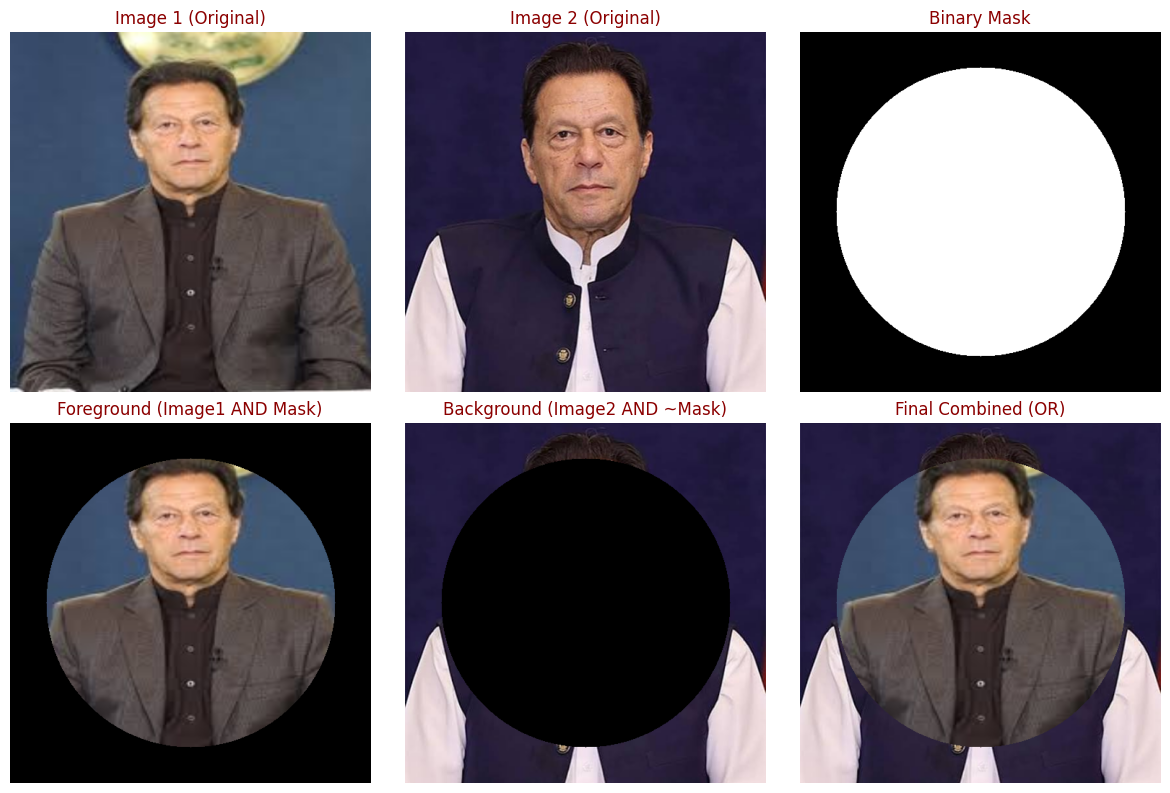

In [76]:
def task8():
    image1 = cv2.imread('image1.jfif')
    image2 = cv2.imread('image2.jfif')

    size=(500, 500)

    image1_resized = cv2.resize(image1, size)
    image2_resized = cv2.resize(image2, size)

    image1_rgb = cv2.cvtColor(image1_resized, cv2.COLOR_BGR2RGB)
    image2_rgb = cv2.cvtColor(image2_resized, cv2.COLOR_BGR2RGB)

    width, height = size

    mask = np.zeros((height, width), dtype=np.uint8)
    center = (width // 2, height // 2)
    radius = int(min(width, height) // 2.5)
    print(radius)

    cv2.circle(mask, center, radius, 255, thickness=-1)

    foreground = cv2.bitwise_and(image1_rgb, image1_rgb, mask=mask)

    inverted_mask = cv2.bitwise_not(mask)
    background = cv2.bitwise_and(image2_rgb, image2_rgb, mask=inverted_mask)

    combined = cv2.bitwise_or(foreground, background)

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 3, 1)
    plt.title("Image 1 (Original)", fontsize=12, color='darkred')
    plt.axis('off')
    plt.imshow(image1_rgb)

    plt.subplot(2, 3, 2)
    plt.title("Image 2 (Original)", fontsize=12, color='darkred')
    plt.axis('off')
    plt.imshow(image2_rgb)

    plt.subplot(2, 3, 3)
    plt.title("Binary Mask", fontsize=12, color='darkred')
    plt.axis('off')
    plt.imshow(mask, cmap='gray')

    plt.subplot(2, 3, 4)
    plt.title("Foreground (Image1 AND Mask)", fontsize=12, color='darkred')
    plt.axis('off')
    plt.imshow(foreground)

    plt.subplot(2, 3, 5)
    plt.title("Background (Image2 AND ~Mask)", fontsize=12, color='darkred')
    plt.axis('off')
    plt.imshow(background)

    plt.subplot(2, 3, 6)
    plt.title("Final Combined (OR)", fontsize=12, color='darkred')
    plt.axis('off')
    plt.imshow(combined)

    plt.tight_layout()
    plt.show()

task8()

### Task 9: Statistical Image Profiling with Pandas

In [77]:
def task9():
    image = cv2.imread('image.jfif')

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    red_channel = image_rgb[:, :, 0].flatten()
    green_channel = image_rgb[:, :, 1].flatten()
    blue_channel = image_rgb[:, :, 2].flatten()

    df = pd.DataFrame({
        'Red': red_channel,
        'Green': green_channel,
        'Blue': blue_channel
    })

    display(df.describe())

task9()

,Red,Green,Blue
count,306685.000000,306685.000000,306685.000000
mean,36.268386,45.815149,53.268455
std,38.932142,31.744651,35.427541
min,0.000000,0.000000,0.000000
25%,14.000000,27.000000,27.000000
50%,21.000000,36.000000,47.000000
75%,45.000000,53.000000,62.000000
max,255.000000,235.000000,231.000000
